# Intrestberekening

In dit voorbeeld berekenen we de intrest over tijd. Daarvoor hebben we de volgende elementen nodig:
- Startbedrag (SB)
- Maandelijks bedrag (MB)
- Uitstaande balans (UB)
- Intrestvoet (i)
- Aantal betalingen (n)

De berekening van het maandbedrag ziet er als volgt uit:
$$MB= SB \cdot \frac{i\cdot (1+i)^n}{(1+i)^n-1}$$

Dit berekenen we eerst:

In [1]:
import numpy as np 

SB = 30000
i = 0.01
n = 10

MB = SB * (i * (1+i)**n)/((1+i)**n-1)
print('Maandelijks bedrag %.2f' % MB)

Maandelijks bedrag 3167.46


Nu gaan we berekenen hoeveel interest en hoeveel van het kapitaal wordt afbetaald:

In [2]:
# uitstaande balans = startbedrag
UB = SB
print('Uitstaande balans begin:', UB)

aantal = 0
while UB > 0:
    aantal += 1
    print(f'\nBetaling {aantal}')
    
    # intrestbetaling
    IP = UB * i
    
    # afbetaling kapitaal
    PP = MB - IP
    
    # updaten uitstaande balans
    UB -= PP
    
    print('Intrest betaald %.2f' % IP)
    print('Uitstaande balans %.2f' % UB)

Uitstaande balans begin: 30000

Betaling 1
Intrest betaald 300.00
Uitstaande balans 27132.54

Betaling 2
Intrest betaald 271.33
Uitstaande balans 24236.40

Betaling 3
Intrest betaald 242.36
Uitstaande balans 21311.30

Betaling 4
Intrest betaald 213.11
Uitstaande balans 18356.95

Betaling 5
Intrest betaald 183.57
Uitstaande balans 15373.06

Betaling 6
Intrest betaald 153.73
Uitstaande balans 12359.33

Betaling 7
Intrest betaald 123.59
Uitstaande balans 9315.46

Betaling 8
Intrest betaald 93.15
Uitstaande balans 6241.15

Betaling 9
Intrest betaald 62.41
Uitstaande balans 3136.10

Betaling 10
Intrest betaald 31.36
Uitstaande balans 0.00

Betaling 11
Intrest betaald 0.00
Uitstaande balans -3167.46


Nu gaan we dit in een NumPy matrix gieten. We maken 4 kolommen: 1 voor het maandelijkse bedrag, 1 om de uitstaande balans bij te houden, 1 voor de intrestcomponent en de laatste om de kapitaalaflossing te dekken. We beginnen door alles op de eerste rij juist in te vullen:

In [3]:
matrix = np.zeros((n, 4))

# maandelijks bedrag in de hele eerste kolom
matrix[:,0] = round(MB, 2)

# startbedrag op de eerste rij
matrix[0,1] = round(SB, 2)

# eerste interestbetaling op de eerste rij
matrix[0,2] = SB * i

matrix

array([[ 3167.46, 30000.  ,   300.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ],
       [ 3167.46,     0.  ,     0.  ,     0.  ]])

Nu gaan we dezelfde berekeningen doen als hiervoor en de matrix met een loop invullen:

In [4]:
for j in range(1, matrix.shape[0]):
    matrix[j,1] = matrix[j-1,1] - MB + matrix[j-1,2]
    matrix[j,2] = matrix[j,1] * i   
matrix

array([[ 3167.46      , 30000.        ,   300.        ,     0.        ],
       [ 3167.46      , 27132.53770346,   271.32537703,     0.        ],
       [ 3167.46      , 24236.40078396,   242.36400784,     0.        ],
       [ 3167.46      , 21311.30249527,   213.11302495,     0.        ],
       [ 3167.46      , 18356.95322369,   183.56953224,     0.        ],
       [ 3167.46      , 15373.06045939,   153.73060459,     0.        ],
       [ 3167.46      , 12359.32876745,   123.59328767,     0.        ],
       [ 3167.46      ,  9315.45975859,    93.15459759,     0.        ],
       [ 3167.46      ,  6241.15205964,    62.4115206 ,     0.        ],
       [ 3167.46      ,  3136.1012837 ,    31.36101284,     0.        ]])

Nu kunnen we makkelijk de kapitaalcomponent in de laatste kolom berekenen:

In [5]:
matrix[:, 3] = matrix[:, 0] - matrix[:, 2]
matrix

array([[ 3167.46      , 30000.        ,   300.        ,  2867.46      ],
       [ 3167.46      , 27132.53770346,   271.32537703,  2896.13462297],
       [ 3167.46      , 24236.40078396,   242.36400784,  2925.09599216],
       [ 3167.46      , 21311.30249527,   213.11302495,  2954.34697505],
       [ 3167.46      , 18356.95322369,   183.56953224,  2983.89046776],
       [ 3167.46      , 15373.06045939,   153.73060459,  3013.72939541],
       [ 3167.46      , 12359.32876745,   123.59328767,  3043.86671233],
       [ 3167.46      ,  9315.45975859,    93.15459759,  3074.30540241],
       [ 3167.46      ,  6241.15205964,    62.4115206 ,  3105.0484794 ],
       [ 3167.46      ,  3136.1012837 ,    31.36101284,  3136.09898716]])

We kunnen dit visualiseren op een grafiek met Matplotlib waarbij de verschillende kolommen over tijd worden geplot. We gebruiken `arange()` om een reeks te maken van de tijdspunten voor op de x-as:

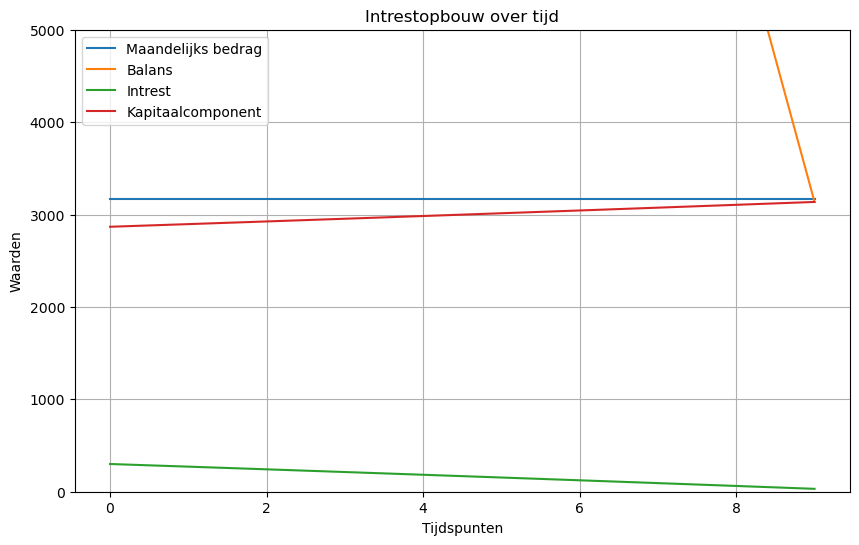

In [6]:
import matplotlib.pyplot as plt

tijdspunten = np.arange(n)

# we maken een figuur-object aan
plt.figure(figsize=(10, 6))

# we plotten alle kolommen
labels = ["Maandelijks bedrag", "Balans", "Intrest", "Kapitaalcomponent"]
for kolom in range(matrix.shape[1]):
    plt.plot(tijdspunten, matrix[:, kolom], label=labels[kolom])

plt.title("Intrestopbouw over tijd")
plt.xlabel("Tijdspunten")
plt.ylabel("Waarden")
# vermits de balans groot is vertekent die de figuur
plt.ylim(0,5000)
plt.legend()
plt.grid()
plt.show()